In [9]:
from typing import TypedDict 
from langgraph.graph import StateGraph, START, END


In [10]:
class AgentState(TypedDict):
    num1:int
    ops:str
    num2:int
    result:int
    
    

In [11]:
def adder(state:AgentState)->AgentState:
    "add two numbers" 
    state['result'] = state['num1'] + state['num2']
    return state


In [12]:
def subtractor(state:AgentState)->AgentState:
    "subtract two numbers"
    state['result'] = state['num1']-state['num2']
    return state


In [13]:
def decide_next_node(state:AgentState)-> AgentState:
    "current node choose the next node of the graph"
    if state['ops'] == '+':
        return 'addition_edge'
    else:
        return 'subtraction_edge'
    
    

In [15]:
graph = StateGraph(AgentState)
graph.add_node('adder',adder)
graph.add_node('subtractor', subtractor)
graph.add_node('router', lambda state:state) #pass through function because its an edge so just need to direct

graph.add_edge(START, 'router')


In [16]:
graph.add_conditional_edges('router', decide_next_node, 
                            {
                                'addition_edge':'adder',
                                'subtraction_edge':'subtractor'
                            }
                            )

In [18]:
graph.add_edge('adder',END)
graph.add_edge('subtractor',END)
app = graph.compile()


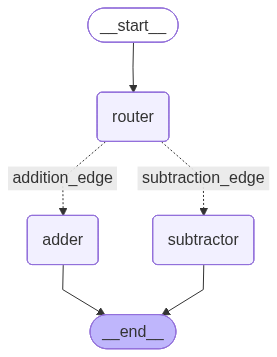

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))